In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score

In [13]:
base_artifacts = Path.cwd().resolve().parents[1] / 'CausalI2I_artifacts'
raw_results = pd.read_csv(base_artifacts / 'Datasets' / 'Sequels' / 'sequels_evaluated.csv')

In [14]:
new_names = {
    'ATE_OM': 'OM',
    'ATE_DR': 'DR',
    'ATE_STABILIZED': 'ATE (stabilized)',
    'cosine_similarity': 'Cosine',
    'correlation': 'Pearson',
    'diff_of_conditionals': 'DoC',
    'jacard_index': 'Jaccard',
    'sasrec_score': 'SASRec'
}
raw_results = raw_results.rename(columns=new_names)

ate = raw_results['ATE'].values
std = raw_results['STD'].values

eps = 0.001
raw_results['STE'] = raw_results[['ATE', 'STD']].apply(lambda row: row['ATE'] / np.max([row['STD'], eps]), axis=1)
raw_results['ABLT/STD'] = raw_results[['ABLT', 'STD_ABLT']].apply(lambda row: row['ABLT'] / np.max([row['STD_ABLT'], eps]), axis=1)
raw_results['DR/STD'] = raw_results[['DR', 'STD_DR']].apply(lambda row: row['DR'] / np.max([row['STD_DR'], eps]), axis=1)
raw_results['STE (stabilized)'] = raw_results[['ATE (stabilized)', 'STD_STABILIZED']].apply(lambda row: row['ATE (stabilized)'] / np.max([row['STD_STABILIZED'], eps]), axis=1)

baselines = ["ATE", "STE", "Pearson", "DoC", "SASRec", "OM", "ABLT", "ABLT/STD", "Cosine", "Jaccard", "DR", "DR/STD", "ATE (stabilized)", "STE (stabilized)"]

In [15]:
Ks = [10, 20, 50, 100, 200, 500, 1000]

vals2plot = {col: None for col in baselines}
for col in baselines:
    col_choises = raw_results.sort_values(by=col, ascending=False)['causal_link'].values
    vals2plot[col] = {K: np.sum(col_choises[:K]) for K in Ks}
total_positives = np.sum(raw_results['causal_link'].values)

summary = {}
for K in Ks:
    summary[('Precision@K (%)', f'K={K}')] = {
        col: 100 * vals2plot[col][K] / K
        for col in baselines}
for K in Ks:
    summary[('Recall@K (%)', f'K={K}')] = {
        col: 100 * vals2plot[col][K] / total_positives
        for col in baselines}
    
summary_df = pd.DataFrame(summary).map(lambda x: f'{x:.2f}')
summary_df

Precision@K (%)                                               \
                            K=10    K=20    K=50   K=100  K=200  K=500 K=1000   
ATE                       100.00  100.00  100.00   99.00  95.50  92.40  88.80   
STE                       100.00  100.00  100.00  100.00  99.50  94.60  91.60   
Pearson                    50.00   50.00   50.00   50.00  50.00  50.00  50.00   
DoC                         0.00   15.00   14.00   17.00  17.00  18.60  21.00   
SASRec                     60.00   55.00   48.00   52.00  42.50  40.20  40.30   
OM                         90.00   90.00   76.00   78.00  74.50  66.00  61.90   
ABLT                      100.00  100.00  100.00  100.00  97.50  96.20  93.90   
ABLT/STD                  100.00  100.00  100.00   98.00  98.00  95.60  93.20   
Cosine                     50.00   50.00   50.00   50.00  50.00  50.00  50.00   
Jaccard                    50.00   50.00   50.00   50.00  50.00  50.00  50.00   
DR                         40.00   25.00   44.00   34.00  33.50  35.60  36.80   
DR/STD                     10.00   20.00   22.00   22.00  20.50  24.60  29.50   
ATE (stabilized)           60.00   75.00   84.00   88.00  88.50  85.80  83.60   
STE (stabilized)           90.00   90.00   94.00   95.00  96.00  95.20  91.50   

                 Recall@K (%)                                        
                         K=10  K=20  K=50 K=100 K=200  K=500 K=1000  
ATE                      0.27  0.54  1.36  2.70  5.20  12.59  24.20  
STE                      0.27  0.54  1.36  2.72  5.42  12.89  24.96  
Pearson                  0.14  0.27  0.68  1.36  2.72   6.81  13.62  
DoC                      0.00  0.08  0.19  0.46  0.93   2.53   5.72  
SASRec                   0.16  0.30  0.65  1.42  2.32   5.48  10.98  
OM                       0.25  0.49  1.04  2.13  4.06   8.99  16.87  
ABLT                     0.27  0.54  1.36  2.72  5.31  13.11  25.59  
ABLT/STD                 0.27  0.54  1.36  2.67  5.34  13.02  25.40  
Cosine                   0.14  0.27  0.68  1.36  2.72   6.81  13.62  
Jaccard                  0.14  0.27  0.68  1.36  2.72   6.81  13.62  
DR                       0.11  0.14  0.60  0.93  1.83   4.85  10.03  
DR/STD                   0.03  0.11  0.30  0.60  1.12   3.35   8.04  
ATE (stabilized)         0.16  0.41  1.14  2.40  4.82  11.69  22.78  
STE (stabilized)         0.25  0.49  1.28  2.59  5.23  12.97  24.93

In [16]:
ap_results = {}
auc_results = {}

summary = {}
y_true = raw_results['causal_link'].values
for col in baselines:
    y_score = raw_results[col].values
    ap = average_precision_score(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    auc_results[col] = auc
    summary[col] = {'AP': ap, 'AUC': auc}

summary_df = pd.DataFrame(summary).map(lambda x: f'{x:.3f}').T
summary_df


,AP,AUC
ATE,0.815,0.815
STE,0.831,0.821
Pearson,0.500,0.500
DoC,0.389,0.336
SASRec,0.450,0.424
OM,0.592,0.610
ABLT,0.828,0.802
ABLT/STD,0.831,0.809
Cosine,0.500,0.500
Jaccard,0.500,0.500


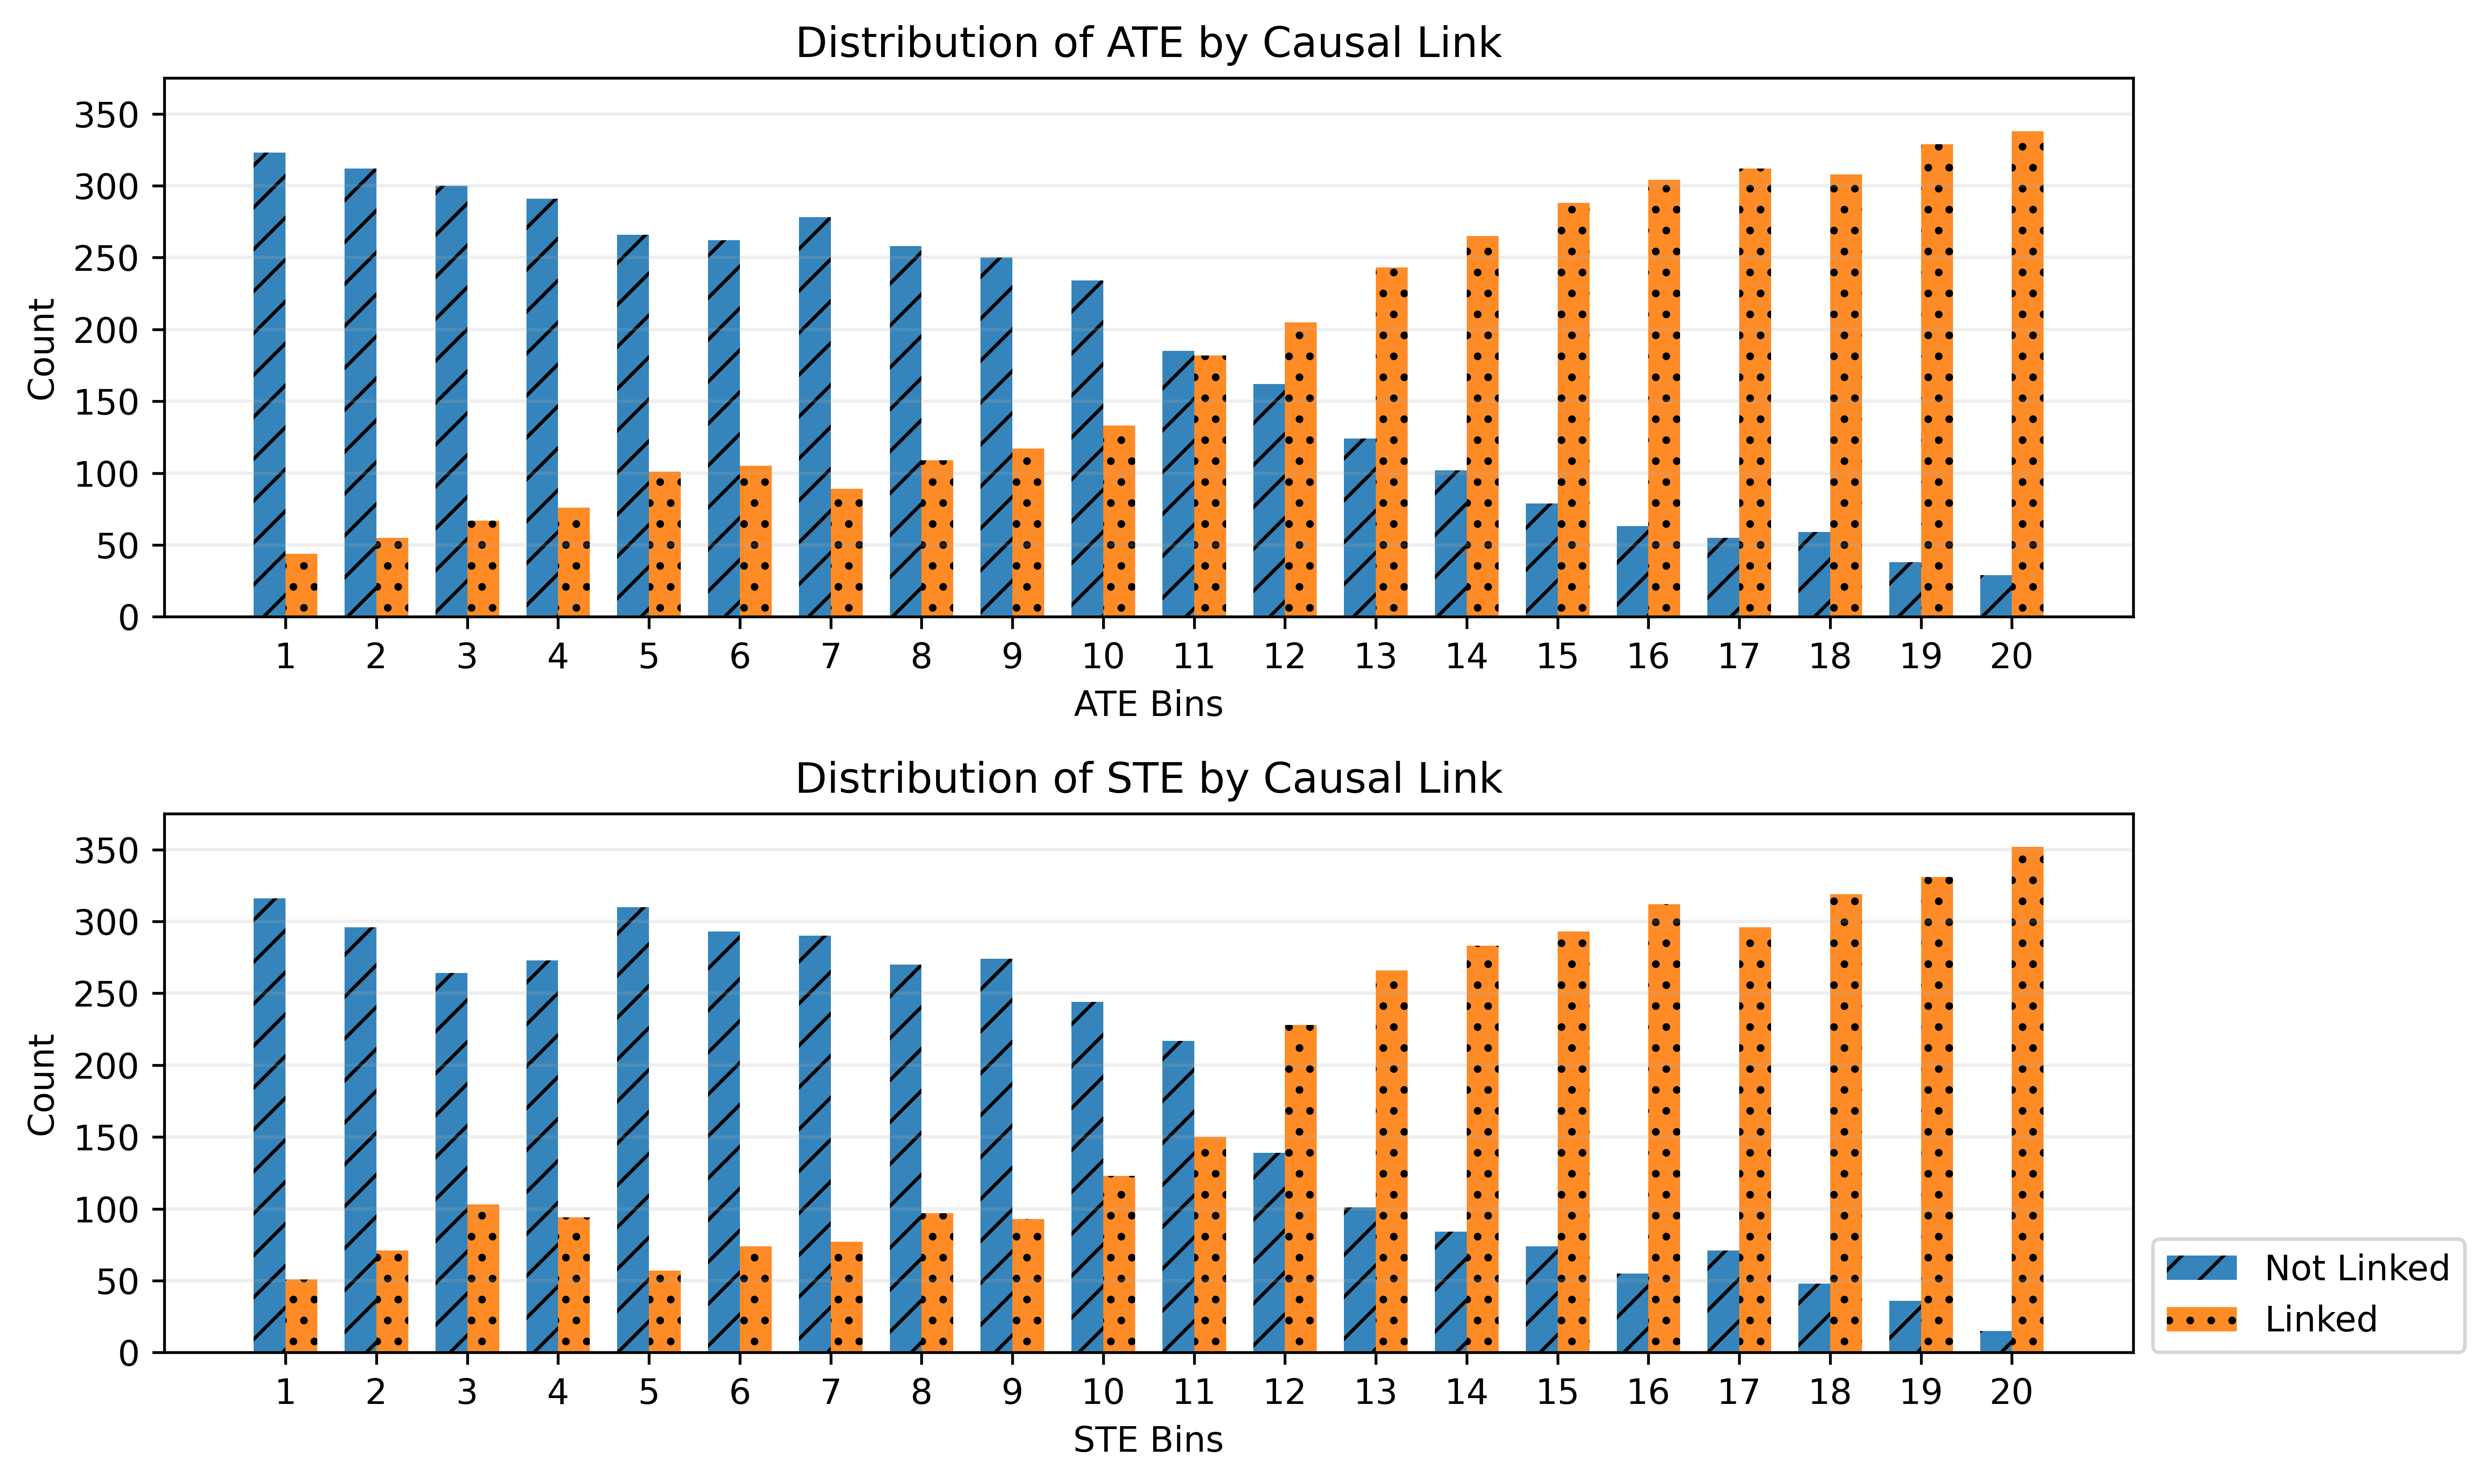

In [17]:
num_bins = 20
w = 0.35
hatches = ['//', '..']

fig, axes = plt.subplots(2, 1, figsize=(10, 6), dpi=600)

for ax, metric in zip(axes, ["ATE", "STE"]):

    # Quantile bins for the current metric
    bins = np.quantile(
        raw_results[metric].values,
        np.arange(0, 1, 1 / num_bins)
    )

    df = raw_results[[metric, 'causal_link']].copy()
    df['metric_bin'] = np.digitize(df[metric], bins) - 1

    for link in [0, 1]:
        subset = df[df['causal_link'] == link]
        counts = subset['metric_bin'].value_counts().sort_index()

        ax.bar(
            counts.index + (link - 0.5) * w,
            counts.values,
            width=w,
            alpha=0.9,
            hatch=hatches[link],
            label='Linked' if link == 1 else 'Not Linked'
        )

    ax.set_xticks(range(num_bins))
    ax.set_xticklabels(range(1, num_bins + 1))
    ax.set_yticks(range(0, 351, 50))
    ax.set_ylim(0, 375)
    ax.set_xlabel(f'{metric} Bins')
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {metric} by Causal Link')

    # ax.set_yscale('log')
    ax.grid(axis='y', which='major', alpha=0.2, linewidth=1)

plt.legend(loc=(1.01, 0))
plt.tight_layout()
plt.savefig(
    base_artifacts / 'Figures' / 'sequels' / 'Binned Precision.jpeg',
    bbox_inches='tight')
plt.show()